<a href="https://colab.research.google.com/github/pranalimohod31/task-17/blob/main/TASK17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd


In [3]:
from google.colab import files
uploaded = files.upload()

Saving heart.xlsx to heart (1).xlsx


In [4]:
import pandas as pd

df = pd.read_excel("heart.xlsx")

df.head(10)

print(df.shape)

df.info()

(918, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
print(df.isnull().sum())

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [6]:
print(df.duplicated().sum())

df = df.drop_duplicates()

print(df.shape)

0
(918, 12)


In [8]:
cholesterol_zero = (df["Cholesterol"] == 0).sum()
restingbp_zero = (df["RestingBP"] == 0).sum()

print("Cholesterol = 0:", cholesterol_zero)
print("RestingBP = 0:", restingbp_zero)

Cholesterol = 0: 172
RestingBP = 0: 1


In [10]:
print("Before Cleaning:")
print(df[["Cholesterol", "RestingBP"]].describe())

chol_mean = df[df["Cholesterol"] != 0]["Cholesterol"].mean()
bp_mean = df[df["RestingBP"] != 0]["RestingBP"].mean()

df["Cholesterol"] = df["Cholesterol"].replace(0, chol_mean)
df["RestingBP"] = df["RestingBP"].replace(0, bp_mean)

df["Cholesterol"] = df["Cholesterol"].round(2)
df["RestingBP"] = df["RestingBP"].round(2)

print("\nAfter Cleaning:")
print(df[["Cholesterol", "RestingBP"]].describe())

Before Cleaning:
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    198.799564  132.396514
std     109.384145   18.514154
min       0.000000    0.000000
25%     173.250000  120.000000
50%     223.000000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000

After Cleaning:
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    244.636253  132.540893
std      53.318029   17.989932
min      85.000000   80.000000
25%     214.000000  120.000000
50%     244.640000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000


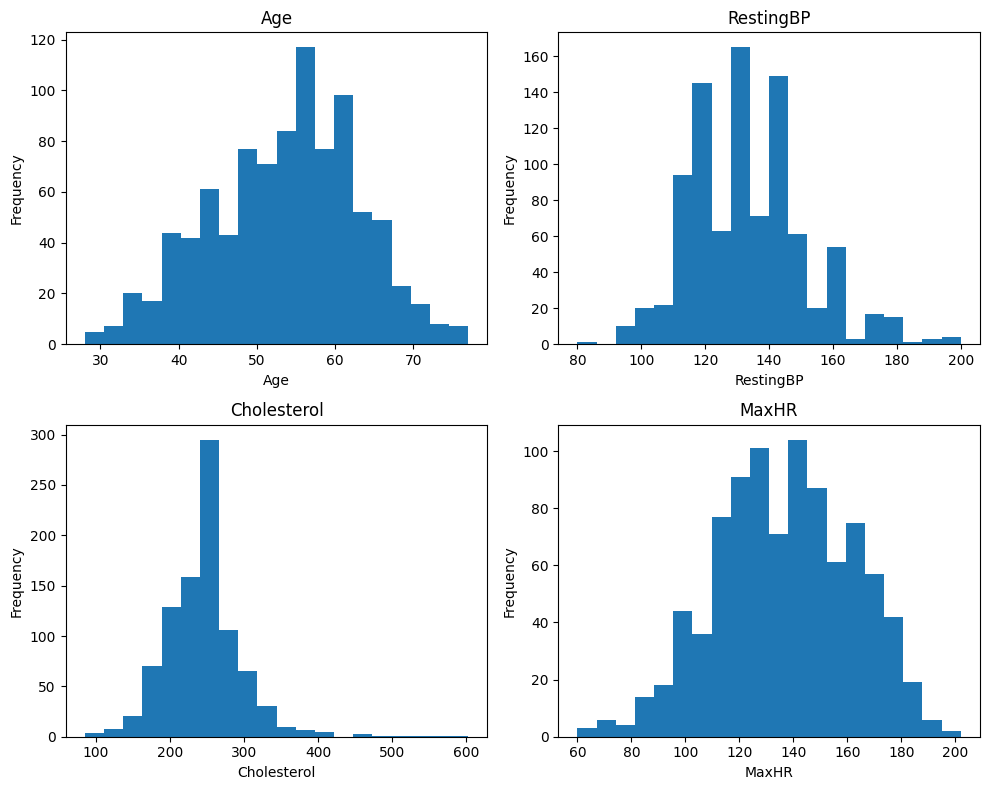

In [11]:
import matplotlib.pyplot as plt

def plot_histogram(column, position):
    plt.subplot(2, 2, position)
    plt.hist(df[column], bins=20)
    plt.title(column)
    plt.xlabel(column)
    plt.ylabel("Frequency")

plt.figure(figsize=(10, 8))

plot_histogram("Age", 1)
plot_histogram("RestingBP", 2)
plot_histogram("Cholesterol", 3)
plot_histogram("MaxHR", 4)

plt.tight_layout()
plt.show()

In [12]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = df.select_dtypes(include=["object"]).columns

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease'],
      dtype='object')

Categorical Columns:
Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')


In [13]:
df_encoded = pd.get_dummies(df)

print(df_encoded.shape)

print(df_encoded.head())

(918, 21)
   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0   40      140.0        289.0          0    172      0.0             0   
1   49      160.0        180.0          0    156      1.0             1   
2   37      130.0        283.0          0     98      0.0             0   
3   48      138.0        214.0          0    108      1.5             1   
4   54      150.0        195.0          0    122      0.0             0   

   Sex_F  Sex_M  ChestPainType_ASY  ...  ChestPainType_NAP  ChestPainType_TA  \
0  False   True              False  ...              False             False   
1   True  False              False  ...               True             False   
2  False   True              False  ...              False             False   
3   True  False               True  ...              False             False   
4  False   True              False  ...               True             False   

   RestingECG_LVH  RestingECG_Normal  RestingECG_ST  Exerc

In [14]:
print(df_encoded.shape)

print(df_encoded.columns.tolist())

(918, 21)
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']


## Summary

- The dataset contained invalid values where **Cholesterol = 0** and **RestingBP = 0**, which are unrealistic for living patients.
- These invalid values were replaced with the **mean** of the respective column, calculated after excluding the zero values. The cleaned values were then rounded to 2 decimal places.
- Handling invalid values is important because they can affect statistical analysis, visualizations, and machine learning models, leading to inaccurate results.
- **One-Hot Encoding** converts categorical columns into numerical columns (0s and 1s), allowing machine learning algorithms to process categorical data effectively.